# Validating an InSAR displacement product against GNSS

End-to-end GNSS-vs-InSAR comparison with geepers, on the small real dataset that
ships with the repository: five Sentinel-1 displacement epochs over Kīlauea,
Hawai'i (July–September 2016) and the UNR GPS stations inside the scene.

The workflow demonstrates every layer of a DISP-style validation:

1. run the full comparison with a **metric circular buffer** around each station,
2. per-station **time-series** comparison,
3. **velocity** scatter (GPS MIDAS vs InSAR),
4. the **structure function** — relative RMSE vs station separation, with a
   requirement curve,
5. **per-epoch network misfit** — flagging bad acquisitions,
6. the effect of the sampling **buffer radius**.

*Needs network access to geodesy.unr.edu the first time (station downloads are
cached afterward).*

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 110

# Locate the repository test data (works when run from docs/notebooks/)
repo = Path.cwd()
while not (repo / "tests" / "data" / "hawaii").exists():
    repo = repo.parent
data_dir = repo / "tests" / "data" / "hawaii"
ts_files = sorted(data_dir.glob("displacement_*.tif"))
print(f"{len(ts_files)} displacement epochs, LOS raster: {data_dir / 'hawaii_los_enu.tif'}")

5 displacement epochs, LOS raster: /u/aurora-r0/govorcin/03_DISP_NI/NISAR-DB/code/geepers/tests/data/hawaii/hawaii_los_enu.tif


## 1. Run the workflow

One call does everything: discovers UNR stations inside the raster bounds,
downloads their ENU series, projects onto the line of sight, samples the InSAR
stack with a **100 m circular median footprint** around every station
(reference and secondary alike), merges by date, and writes all comparison
products — including the structure function checked against a
`3 mm + 0.5 mm·√(d_km)` requirement curve.

In [2]:
from geepers.workflows import main

out_dir = Path("validation_output")
main(
    los_enu_file=data_dir / "hawaii_los_enu.tif",
    timeseries_files=ts_files,
    output_dir=out_dir,
    insar_buffer_meters=100.0,
    requirement_mm=(3.0, 0.5),
)
sorted(p.name for p in out_dir.iterdir())

/u/aurora-r0/govorcin/miniconda/miniforge/envs/geepers-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Projecting GPS -> LOS:   0%|          | 0/10 [00:00<?, ?it/s]

Projecting GPS -> LOS: 100%|██████████| 10/10 [00:00<00:00, 225.72it/s]

Sampling band_data (buffer 100.0 m):   0%|          | 0/343 [00:00<?, ?it/s]

Sampling band_data (buffer 100.0 m): 100%|██████████| 343/343 [00:00<00:00, 3683.21it/s]

...

No data for station PUHR


No common epochs between DVLT and CRIM


No common epochs between PUHI and CRIM


No common epochs between PUHR and CRIM


['combined_data.csv',
 'epoch_rmse.csv',
 'pairwise_rmse.csv',
 'relative_comparison.csv',
 'rmse_profile.csv',
 'station_summary.csv',
 'structure_function.png']

## 2. Time-series comparison per station

`combined_data.csv` holds the tidy per-station GPS and InSAR LOS series.
With only five epochs over two months this dataset is a smoke test, but the
plots show exactly what a full DISP validation looks like.

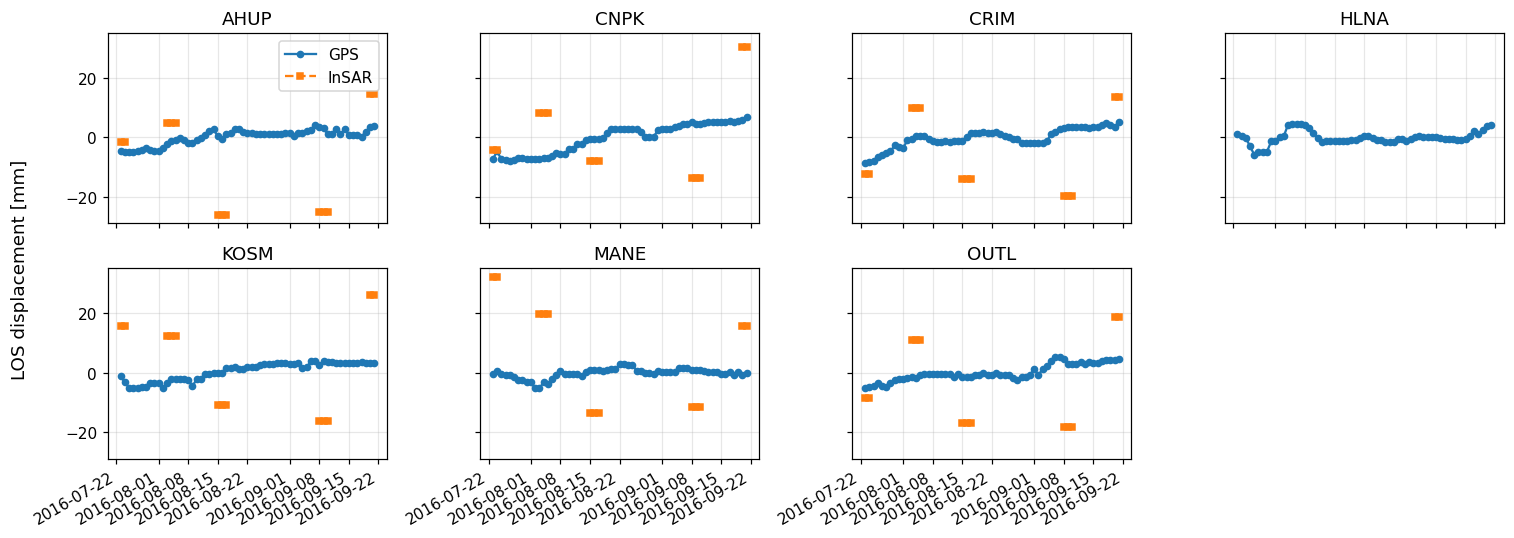

In [3]:
df = pd.read_csv(out_dir / "combined_data.csv", parse_dates=["date"])
wide = df.pivot_table(index=["id", "date"], columns="measurement", values="value").reset_index()
stations = sorted(wide["id"].unique())

fig, axes = plt.subplots(2, 4, figsize=(14, 5), sharex=True, sharey=True)
for ax, sid in zip(axes.ravel(), stations, strict=False):
    sub = wide[wide["id"] == sid]
    ax.plot(sub["date"], sub["los_gps"] * 1000, "o-", ms=4, label="GPS")
    ax.plot(sub["date"], sub["los_insar"] * 1000, "s--", ms=4, label="InSAR")
    ax.set_title(sid)
    ax.grid(alpha=0.3)
for ax in axes.ravel()[len(stations):]:
    ax.set_visible(False)
axes[0, 0].legend()
fig.supylabel("LOS displacement [mm]")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 3. Velocity comparison (same estimator on both series)

Comparing a MIDAS GPS rate against a least-squares InSAR rate mixes estimator
differences into the product assessment. `geepers.validation.fit_velocities`
fits the **same** estimator to both series — `midas` for records longer than a
year, `lsq` for this short demo — and `plot_velocity_scatter` reports
bias, scaled MAD, RMSE and R² against the 1:1 line.

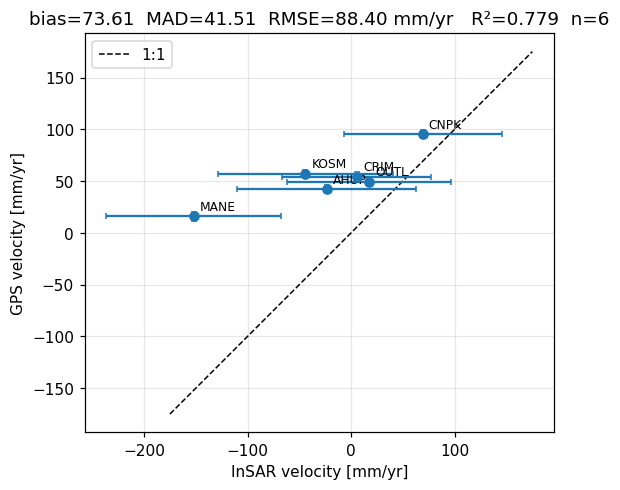

In [4]:
from geepers.validation import fit_velocities, plot_velocity_scatter

# rebuild the merged per-station tables from the tidy CSV
# (skip stations whose InSAR samples are all-NaN, e.g. outside the raster)
merged = {}
for sid, g in df.groupby("id"):
    piv = g.pivot_table(index="date", columns="measurement", values="value")
    if {"los_gps", "los_insar"} <= set(piv.columns):
        merged[sid] = piv

vel = fit_velocities(merged, method="lsq")   # use method="midas" for 1+ yr records
plot_velocity_scatter(vel, units="mm/yr", scale=1000)
plt.show()

## 4. Structure function: relative RMSE vs distance

For every station pair, the two LOS series are differenced *before*
comparison, so any common reference/datum wobble cancels — this measures the
product's **relative** accuracy the way OPERA requirements are written.

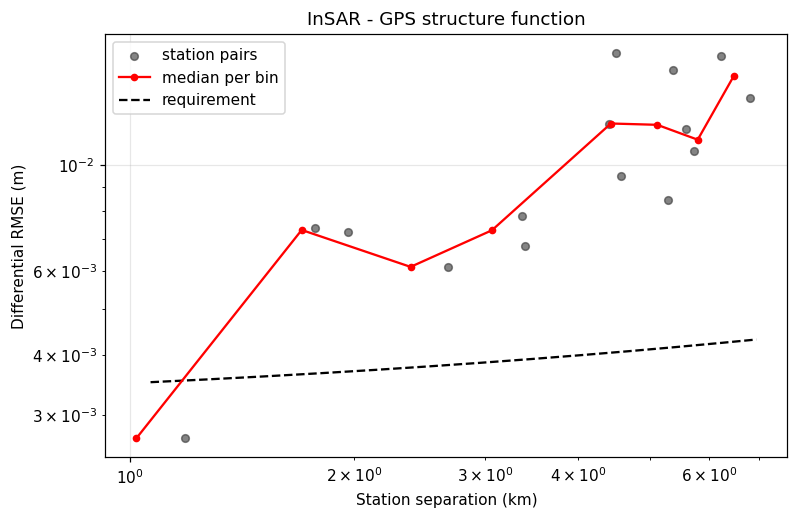

   distance_km  rmse_median  n_pairs  fraction_passing
0       1.0210       0.0027        1               1.0
1       1.7016       0.0073        2               0.0
2       2.3823       0.0061        1               0.0
3       3.0629       0.0073        2               0.0
4       4.4242       0.0122        3               0.0
5       5.1048       0.0121        2               0.0
6       5.7855       0.0113        2               0.0
7       6.4661       0.0153        2               0.0


In [5]:
from geepers.plotting import plot_rmse_vs_distance

rmse_df = pd.read_csv(out_dir / "pairwise_rmse.csv")
profile = pd.read_csv(out_dir / "rmse_profile.csv")
def req(d):
    return (3 + 0.5 * np.sqrt(d)) / 1000  # same curve the workflow used

ax = plot_rmse_vs_distance(rmse_df, profile, requirement=req)
plt.show()

if "fraction_passing" in profile.columns:
    print(profile[["distance_km", "rmse_median", "n_pairs", "fraction_passing"]].round(4).to_string())

### Semivariogram view

The same pairwise misfits as a semivariogram (`gamma = rmse²/2`), with
log-log, log-x or linear axes — log-log is the geostatistical convention
for reading off the correlation structure of the residual field.

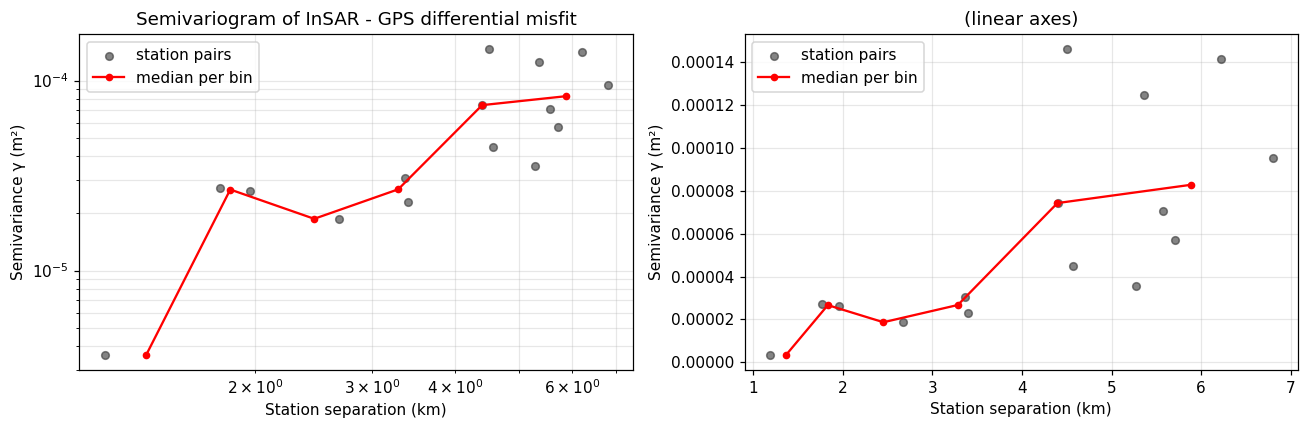

In [6]:
from geepers.validation import misfit_semivariogram, plot_semivariogram

svg = misfit_semivariogram(rmse_df, n_bins=6, log_bins=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_semivariogram(rmse_df, svg, scale="loglog", ax=axes[0])
plot_semivariogram(rmse_df, svg, scale="linear", ax=axes[1])
axes[1].set_title("(linear axes)")
plt.tight_layout()
plt.show()

## 5. Per-epoch network misfit

The RMSE across stations at each date (after removing the network median)
isolates *acquisition-level* problems: an ionospheric storm or unwrapping
failure shows up as a spike on this plot.

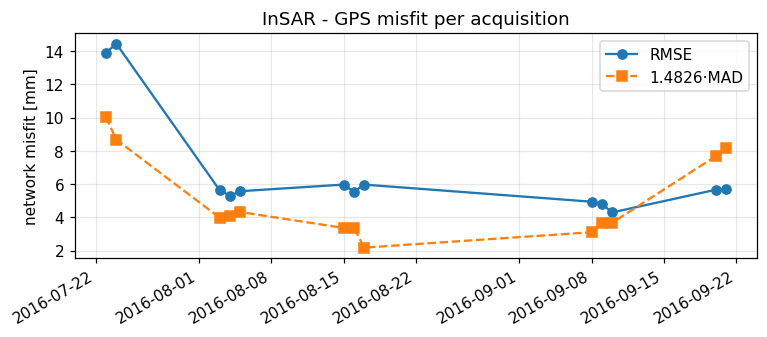

In [7]:
epoch = pd.read_csv(out_dir / "epoch_rmse.csv", index_col=0, parse_dates=True)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(epoch.index, epoch["rmse"] * 1000, "o-", label="RMSE")
ax.plot(epoch.index, epoch["mad"] * 1000, "s--", label="1.4826·MAD")
ax.set_ylabel("network misfit [mm]")
ax.grid(alpha=0.3); ax.legend()
ax.set_title("InSAR - GPS misfit per acquisition")
fig.autofmt_xdate()
plt.show()

## 6. Effect of the sampling buffer

Sampling a single pixel at a GPS station is noisy; a large buffer mixes in
different ground motion. `sample_insar` with `buffer_meters` uses a circular
median footprint — compare radii directly:

Sampling band_data (buffered by 0 pixels):   0%|          | 0/106 [00:00<?, ?it/s]

Sampling band_data (buffered by 0 pixels): 100%|██████████| 106/106 [00:00<00:00, 1783.54it/s]

Sampling band_data (buffer 100.0 m):   0%|          | 0/343 [00:00<?, ?it/s]

Sampling band_data (buffer 100.0 m): 100%|██████████| 343/343 [00:00<00:00, 4164.41it/s]

Sampling band_data (buffer 500.0 m):   0%|          | 0/698 [00:00<?, ?it/s]

Sampling band_data (buffer 500.0 m):  68%|██████▊   | 478/698 [00:00<00:00, 4779.56it/s]

Sampling band_data (buffer 500.0 m): 100%|██████████| 698/698 [00:00<00:00, 4846.79it/s]

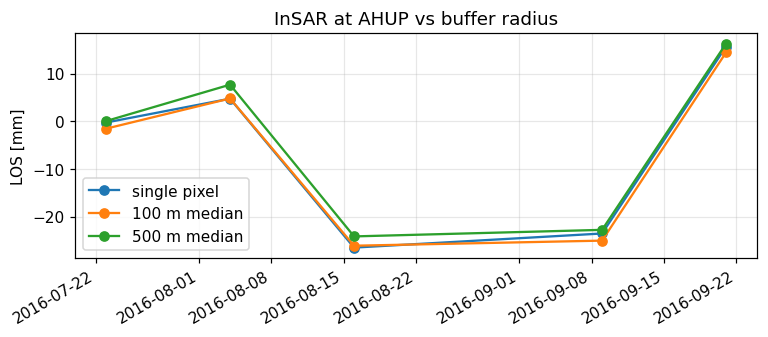

In [8]:
from geepers.gps_sources import UnrSource
from geepers.io import XarrayReader
from geepers.processing import sample_insar

reader = XarrayReader.from_file_list(ts_files)
src = UnrSource()
import rasterio.warp

bounds = rasterio.warp.transform_bounds(reader.crs, "EPSG:4326", *reader.da.rio.bounds())
sta = src.stations(bbox=bounds).set_index("id")

fig, ax = plt.subplots(figsize=(8, 3))
for radius in (None, 100.0, 500.0):
    vals = sample_insar(reader, sta, buffer_pixels=0, buffer_meters=radius)
    label = "single pixel" if radius is None else f"{radius:.0f} m median"
    ax.plot(reader.da.time, vals[0] * 1000, "o-", label=label)
ax.set_ylabel("LOS [mm]"); ax.set_title(f"InSAR at {sta.index[0]} vs buffer radius")
ax.grid(alpha=0.3); ax.legend()
fig.autofmt_xdate()
plt.show()

## Where to go next

- Scale this to a real DISP stack: same command with
  `--timeseries-stack product.zarr --wavelength 0.2384` (NISAR L-band).
- Requirement compliance table: `rmse_profile.csv` / `fraction_passing`.
- Method details: [Background theory](../background-theory.md);
  recipes: [How-To Guides](../how-to-guides.md).